# Prática 4 - Regressão

In [ ]:
# Bibliotecas
import pandas as pd
from sklearn import linear_model
from sklearn import tree
import matplotlib.pyplot as plt

In [3]:
# Carregando os dados
df = pd.read_excel('../data/dados_cerveja_nota.xlsx', index_col = 0)
df.head()

,cerveja,nota
id,,
1,1,0.75
2,1,3.00
3,2,1.75
4,3,1.75
5,4,4.20


In [ ]:
# Separando features e target
X = df[['cerveja']] # Curiosidade: É maiúsculo, pois é sempre uma matriz
y = df['nota']

display(X.head())
display(y.head())

,cerveja
id,
1,1
2,1
3,2
4,3
5,4


id
1    0.75
2    3.00
3    1.75
4    1.75
5    4.20
Name: nota, dtype: float64

## Regressão

In [ ]:
# Criando o modelo de regressão linear
regressao = linear_model.LinearRegression() # Podemos colocar o fit_intercept, pois é o nosso coef. linear da reta, ou seja, podemos alocar ele. 

# Treinando o modelo
regressao.fit(X, y)


,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [12]:
# Podemos ver os valores de w e b que foram encontrados
print(f'w: {regressao.coef_}')
print(f'b: {regressao.intercept_}')



w: [1.03629032]
b: 0.151612903225808


## Árvore

In [ ]:
# Criando o modelo de árvore de regressão
arvore_full = tree.DecisionTreeRegressor(random_state = 2026)
arvore = tree.DecisionTreeRegressor(random_state = 2026, max_depth = 1) # max_depth é o nível de profundidade máxima da árvore

# Treinando o modelo
arvore_full.fit(X, y)
arvore.fit(X, y)

,"criterion criterion: {""squared_error"", ""friedman_mse"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in the half mean Poisson deviance to find splits... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion.",'squared_error'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",1
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",2026
,"max_le

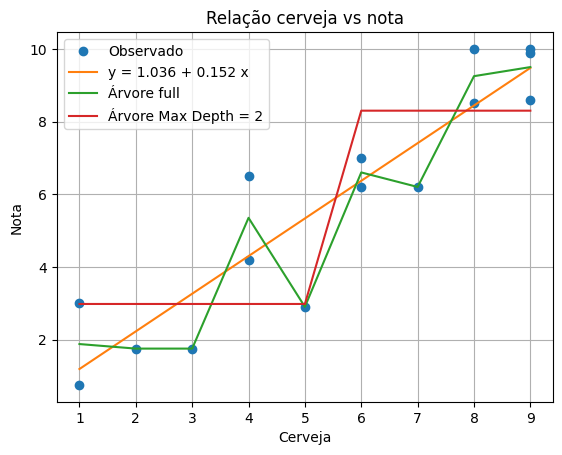

In [ ]:
# Predizendo alguns valores 
predict_reg = regressao.predict(X.drop_duplicates())
predict_arvore_full = arvore_full.predict(X.drop_duplicates())
predict_arvore = arvore.predict(X.drop_duplicates())

plt.plot(X['cerveja'], y, 'o')
plt.grid(True)
plt.title('Relação cerveja vs nota')
plt.xlabel('Cerveja')
plt.ylabel('Nota')

# Desenhando a reta
plt.plot(X.drop_duplicates()['cerveja'], predict_reg)
plt.plot(X.drop_duplicates()['cerveja'], predict_arvore_full)
plt.plot(X.drop_duplicates()['cerveja'], predict_arvore)

# Legenda
plt.legend(['Observado', f'y = {regressao.coef_[0]:.3f} + {regressao.intercept_:.3f} x', 'Árvore full', 'Árvore Max Depth = 1'])


[Text(0.5, 0.75, 'cerveja <= 5.5\nsquared_error = 9.772\nsamples = 15\nvalue = 5.817'),
 Text(0.25, 0.25, 'squared_error = 3.126\nsamples = 7\nvalue = 2.979'),
 Text(0.375, 0.5, 'True  '),
 Text(0.75, 0.25, 'squared_error = 2.372\nsamples = 8\nvalue = 8.3'),
 Text(0.625, 0.5, '  False')]

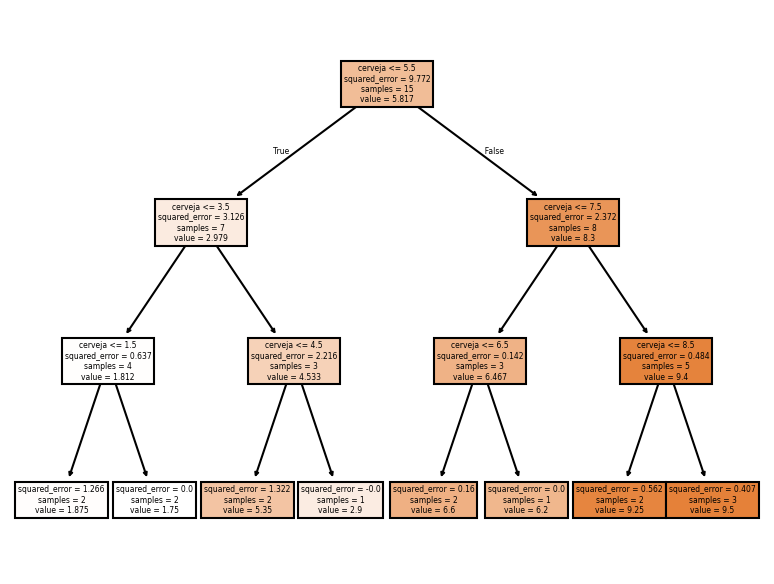

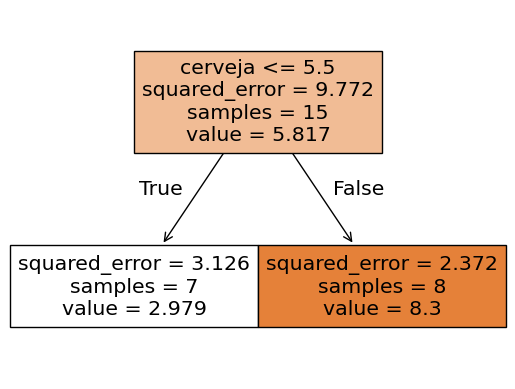

In [39]:
# Vamos plotar as árvores 
# Árvore full
plt.figure(dpi = 150)

tree.plot_tree(
    arvore_full,
    feature_names = ['cerveja'],
    filled = True
)

plt.figure(dpi = 100)

tree.plot_tree(
    arvore,
    feature_names = ['cerveja'],
    filled = True
)